# Explain Model Predictions with SHAP, Part A — Iris Classification

Your k-NN classifier says a flower is *setosa* — but **on what evidence**? Accuracy tells you the model is right often; it does not tell you **why** it chose that label for one specific flower.

In this lesson we learn to:

- Explain **why** a model made a specific prediction for one example.
- Summarize **which features matter most** across many predictions.
- Use **[SHAP](https://shap.readthedocs.io/en/latest/index.html)** (SHapley Additive exPlanations) as a model-agnostic explanation method.
- Apply SHAP to the **k-NN classifier** from the previous lesson on the Iris dataset.


In [1]:
# https://pandas.pydata.org/docs/
import pandas as pd

# https://numpy.org/doc/stable/
import numpy as np

# https://matplotlib.org/
import matplotlib.pyplot as plt

# https://seaborn.pydata.org/
import seaborn as sns

# https://shap.readthedocs.io/en/latest/index.html
import shap

# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html
from sklearn.datasets import load_iris

# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
from sklearn.model_selection import train_test_split

# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
from sklearn.preprocessing import StandardScaler

# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
from sklearn.neighbors import KNeighborsClassifier

# https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html
from sklearn.pipeline import make_pipeline

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html
from sklearn.metrics import accuracy_score

sns.set_theme(style="whitegrid")

## 1. Why we need a common explanation language

Different models answer *"which feature matters?"* in incompatible ways:

- **Linear regression** points at the size of a **coefficient**.
- **k-NN** has no coefficients — it votes among nearby training points.

You cannot compare a coefficient to a neighbor vote. Before trusting a model in production, you often need one explanation format that works for **any** model.

**SHAP** does exactly that. It expresses every prediction as:

$$f(x) = \text{base value} + \sum_j \text{SHAP}_j(x)$$

- The **base value** is what the model would predict on average (with no feature information).
- Each **SHAP value** $\text{SHAP}_j(x)$ is that feature's fair share of pushing the prediction above or below that average.
- The values are **additive**: base + all contributions = the final prediction.


### Shapley values in plain language

SHAP builds on **Shapley values** from cooperative game theory.

Imagine features as players who jointly produce a prediction score. The question is: *how much credit does each player deserve?*

- A feature might matter a lot when added **early** (before correlated features are present).
- The same feature might matter little when added **late** (after correlated features already explained the outcome).
- SHAP averages the marginal contribution of each feature over **all possible orderings** in which features could be revealed.

That average is the feature's Shapley value — a principled, model-agnostic attribution.


## 2. Load the Iris dataset

We reuse the classic [Iris](https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html) dataset — the same flowers you classified in the k-NN exercise.

- **4 numeric features:** sepal length/width, petal length/width (in cm).
- **3 classes:** setosa, versicolor, virginica.
- **150 samples** — small enough to run SHAP quickly, rich enough to see clear patterns.


In [2]:
iris = load_iris(as_frame=True)

X = iris.data
y = iris.target

# Map integer codes to readable species names for plots and interpretation
class_names = iris.target_names.tolist()
y_named = y.map(dict(enumerate(class_names)))

print(f"Samples: {X.shape[0]}   Features: {X.shape[1]}   Classes: {len(class_names)}")
X.head()

Samples: 150   Features: 4   Classes: 3


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
y_named.head()

0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: target, dtype: str

## 3. Train a k-NN classifier

We fit the same style of model you already know from [lesson 05](05_knn_classification.ipynb):

- `StandardScaler` so no single measurement dominates the distance.
- `KNeighborsClassifier` with $k = 5$ neighbors.
- `stratify=y` so each species appears in the same proportion in train and test.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  # hold out 20% for evaluation and SHAP examples
    random_state=42,  # reproducible split
    stratify=y,  # keep class proportions in both subsets
)

pipe = make_pipeline(
    StandardScaler(),  # z-score each feature on the training set
    KNeighborsClassifier(
        n_neighbors=5,  # majority vote among 5 nearest training flowers
    ),
)
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.1%}")

Test accuracy: 93.3%


## 4. Build a SHAP explainer

SHAP needs two ingredients:

1. **A prediction function** — here `pipe.predict_proba`, which returns a probability for each class.
2. **Background data** — a reference distribution of "typical" flowers. SHAP compares each test flower against this background to measure how each feature shifts the probabilities.

Because Iris is tiny, we sample 50 training flowers as background. On larger datasets you would summarize the background with fewer representative points (for example `shap.kmeans`).


In [5]:
# Representative background flowers drawn from the training set
background = shap.utils.sample(
    X_train,
    50,  # enough variety without making every explanation painfully slow
)

explainer = shap.Explainer(
    pipe.predict_proba,  # explain class probabilities, not just the hard label
    background,  # reference distribution for the base value
)

shap_values = explainer(X_test)

print(f"SHAP array shape: {shap_values.shape}")
print("  (test samples, features, classes)")

SHAP array shape: (30, 4, 3)
  (test samples, features, classes)


The returned object has shape `(n_test, n_features, n_classes)`.

- For each test flower and each class, SHAP stores how much every feature pushed that class's **probability** up or down relative to the background average.
- Positive SHAP $\Rightarrow$ the feature made that class **more likely**.
- Negative SHAP $\Rightarrow$ the feature made that class **less likely**.


## 5. Explain one prediction — waterfall plot

A **waterfall plot** tells the story of a single prediction:

1. Start at the **base value** — the average predicted probability for that class across the background.
2. Each bar is one feature's SHAP contribution (red = pushes probability up, blue = pushes down).
3. Land at the **final predicted probability** for that class on this flower.

Because SHAP values are additive, `base + sum(SHAP) = final probability`.


In [6]:
# Pick one test flower and the class the model assigns the highest probability
sample_idx = 0
proba = pipe.predict_proba(X_test.iloc[[sample_idx]])[0]
predicted_class = int(proba.argmax())

print(f"Flower index in test set: {sample_idx}")
print(f"Predicted species: {class_names[predicted_class]}")
print("Class probabilities:")
for name, p in zip(class_names, proba):
    print(f"  {name}: {p:.3f}")

Flower index in test set: 0
Predicted species: setosa
Class probabilities:
  setosa: 1.000
  versicolor: 0.000
  virginica: 0.000


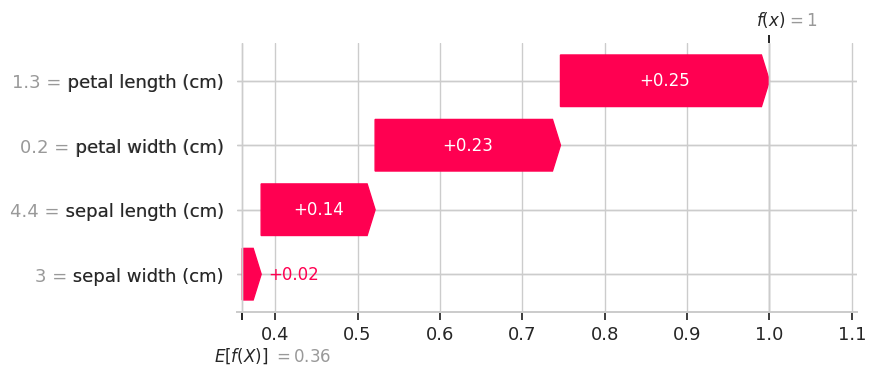

In [7]:
# SHAP values for this flower, for the predicted class only
shap_one = shap_values[sample_idx, :, predicted_class]

shap.plots.waterfall(shap_one)

**How to read the waterfall:**

- Look for the **largest bars** — those features drove the decision most for this flower.
- On Iris, **petal length** and **petal width** usually dominate; that matches botany (setosa is visually separable by petal size alone).
- A feature bar near zero means that measurement was **not decisive** for this particular prediction.


## 6. Global feature importance — bar plot

To see which features matter **on average** across the whole test set, we average the **absolute** SHAP values per feature.

- This answers: *"Which measurements does the model rely on most overall?"*
- It does **not** show direction (up vs down) — only magnitude.

We focus on one target class at a time (here, setosa = class 0).


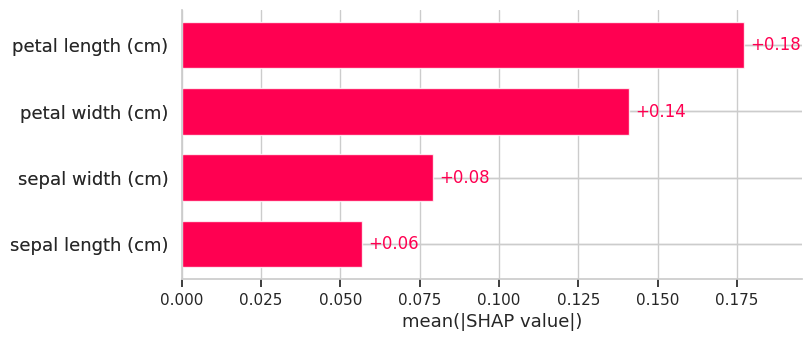

In [8]:
target_class = 0  # setosa
shap_class = shap_values[:, :, target_class]

shap.plots.bar(shap_class)

**Interpretation:**

- Features at the top of the bar chart have the largest average impact on the model's probability output for **setosa**.
- If petal features rank highest, the k-NN model is leaning on the same signal a botanist would — even though k-NN never learned explicit rules or coefficients.


## 7. Distribution of effects — beeswarm plot

The **beeswarm plot** shows every test flower at once:

- **Horizontal position:** SHAP value (how much the feature shifted the probability).
- **Color:** the feature's actual value for that flower (red = high, blue = low).
- **Vertical axis:** features ranked by average impact.

This reveals both **importance** and **direction**:

- Dots far to the right mean *high feature values pushed the class probability up*.
- Dots far to the left mean *low feature values pushed the class probability down*.


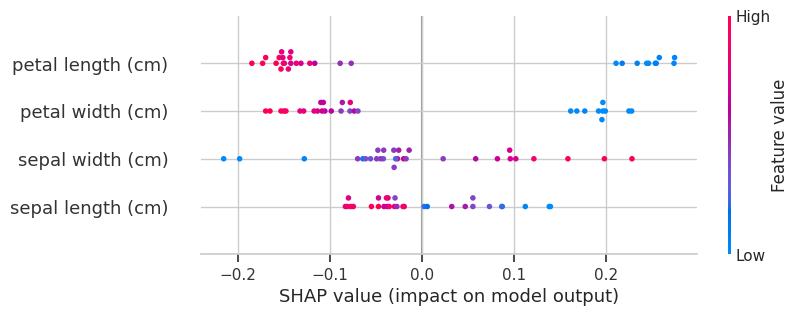

In [9]:
shap.plots.beeswarm(shap_class)

**What to look for on Iris:**

- **Petal length / width** should show the widest spread — many dots far from zero.
- For setosa, high petal values (red dots) often sit on the **left** (negative SHAP) because setosa has unusually *small* petals; the model learns that pattern through neighbor votes.
- Sepal measurements typically matter less, appearing as tighter clouds near zero.


## Recap

- **Accuracy** tells you *how often* the model is right; **SHAP** tells you *why* for each prediction.
- SHAP values are **additive** and **model-agnostic** — the same language works for k-NN today and for other models you will meet later.
- **Waterfall** plots explain one prediction; **bar** and **beeswarm** plots summarize patterns across many predictions.
- On Iris, SHAP usually confirms that **petal measurements** drive k-NN decisions — the same signal visible in the scatter plots from the classification exercise.

Next, [part B](06b_xai_california_housing.ipynb) applies SHAP to a **linear regression** model on the California housing dataset, where the additive story maps cleanly onto learned coefficients.

## References

- [SHAP documentation](https://shap.readthedocs.io/en/latest/index.html)
- [Iris classification with scikit-learn (original SHAP notebook)](https://shap.github.io/shap/notebooks/Iris%20classification%20with%20scikit-learn.html)
- [SHAP chapter — Interpretable Machine Learning (Molnar)](https://christophm.github.io/interpretable-ml-book/shap.html)
- [k-NN classification lesson](05_knn_classification.ipynb)
